<a href="https://colab.research.google.com/github/diaoumardia2001-beep/DI-Bootcamp-May/blob/main/XP_Exercises_Flower_Classification_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XP Exercises: Flower Classification using CNN

This is a guided notebook for the exercises on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts that unlock intuition or transfer to other ML topics.


## What you will learn
- Building a CNN for multi class image classification
- Data loading and preprocessing with `image_dataset_from_directory`
- Image visualization techniques
- Model architecture design, compilation, and training
- Evaluating model performance with accuracy and loss plots


## What you will create
A CNN model that classifies 14 flower species.
All parts form one continuous exercise. Work through them sequentially.


## Dataset
**As stated in the exercises**  
Flower classification with 14 classes. Images are organized in class folders. A training and validation split may be provided. Images are resized to 256x256 in this notebook.

**PREFILLED info**  
This notebook expects the provided zip file to be available. The code below extracts it and locates the dataset root automatically.


In [1]:
import os, sys, zipfile, shutil, glob, math, json, random
from pathlib import Path

DATA_ZIP = Path("/content/Flower Classification.zip")
EXTRACT_DIR = Path("./data/flower_data")

# Clean extract dir if re-running
if EXTRACT_DIR.exists():
    pass  # avoid deleting in case you added files; delete manually if needed
else:
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Extract if a zip is present and not already extracted
if DATA_ZIP.exists():
    marker = EXTRACT_DIR / ".extracted"
    if not marker.exists():
        try:
            with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
                zf.extractall(EXTRACT_DIR)
            marker.write_text("ok")
            print("Extracted:", DATA_ZIP.name, "->", EXTRACT_DIR)
        except zipfile.BadZipFile:
            print(f"Error: The file {DATA_ZIP.name} is not a valid zip file. Please ensure it is uncorrupted and properly uploaded.")
        except Exception as e:
            print(f"An unexpected error occurred during extraction: {e}")
    else:
        print("Already extracted. Skipping.")
else:
    print("Zip file not found at", DATA_ZIP)

# Find candidate dataset roots: a dir with >= 10 subdirs assumed as classes, or contains train/val
def list_dirs(p):
    return [d for d in Path(p).iterdir() if d.is_dir()]

candidates = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    if len([d for d in Path(root).iterdir() if Path(d).is_dir()]) >= 10:
        candidates.append(Path(root))
    if "train" in [d.name.lower() for d in list_dirs(root)] and "val" in [d.name.lower() for d in list_dirs(root)]:
        candidates.append(Path(root))

candidates = sorted(set(candidates))
print("Candidate dataset roots:", [str(c) for c in candidates][:5])

Extracted: Flower Classification.zip -> data/flower_data
Candidate dataset roots: ['data/flower_data/Data', 'data/flower_data/Data/train', 'data/flower_data/Data/val']


## Part 1. Data exploration and visualization

**As stated in the exercises**  
Load the dataset using `image_dataset_from_directory`. Print number of images per class. Modify `visualize_images` to show a 3x3 grid for each class with the class name as the grid title. Analyze challenges you anticipate when classifying the flowers such as similar colors or shapes and intra class variation.


**Guidance**  
If a `train` or `val` folder exists, use them. Otherwise create a split from a single root with `validation_split` and `subset`. Images are resized to 256x256 RGB.


> **IMPORTANT:** we fix a low resultion for images in IMG_SIZE=(32,32) for faster training, however you can change it if you want to test out other resolutions

In [2]:
# PREFILLED: just execute
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def detect_layout(root: Path):
    root = Path(root)
    sub = [d.name.lower() for d in root.iterdir() if d.is_dir()]
    if "train" in sub and "val" in sub:
        return "provided_split", root
    return "single_root", root

# Choose a root
if 'candidates' in globals() and len(candidates) > 0:
    DS_ROOT = candidates[0]
else:
    DS_ROOT = EXTRACT_DIR  # fallback

layout, base = detect_layout(DS_ROOT)
print("Layout:", layout, "Base:", base)

Layout: provided_split Base: data/flower_data/Data


In [3]:
# PREFILLED: just execute
if layout == "provided_split":
    train_dir = next((p for p in base.iterdir() if p.name.lower()=="train"))
    val_dir   = next((p for p in base.iterdir() if p.name.lower()=="val"))
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
else:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="training", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="validation", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", num_classes, class_names)

# Cache and prefetch
def prepare(ds):
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare(train_ds)
val_ds = prepare(val_ds)

Found 13642 files belonging to 14 classes.
Found 98 files belonging to 14 classes.
Classes: 14 ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']


In [4]:
# PREFILLED: just execute — count images per class by scanning directory
from collections import Counter
import os

def count_images_per_class(root):
    counts = {}
    for cls in class_names:
        # find folder named like cls at any depth under base
        matches = list(Path(base).rglob(cls))
        if matches:
            folder = matches[0]
            img_count = sum(1 for p in folder.rglob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp",".gif"})
            counts[cls] = img_count
        else:
            counts[cls] = None
    return counts

base = "/content/data/flower_data/Data/train"
counts = count_images_per_class(base)
counts

{'astilbe': 726,
 'bellflower': 872,
 'black_eyed_susan': 986,
 'calendula': 1011,
 'california_poppy': 1021,
 'carnation': 924,
 'common_daisy': 978,
 'coreopsis': 1035,
 'dandelion': 1038,
 'iris': 1041,
 'rose': 986,
 'sunflower': 1013,
 'tulip': 1034,
 'water_lily': 977}

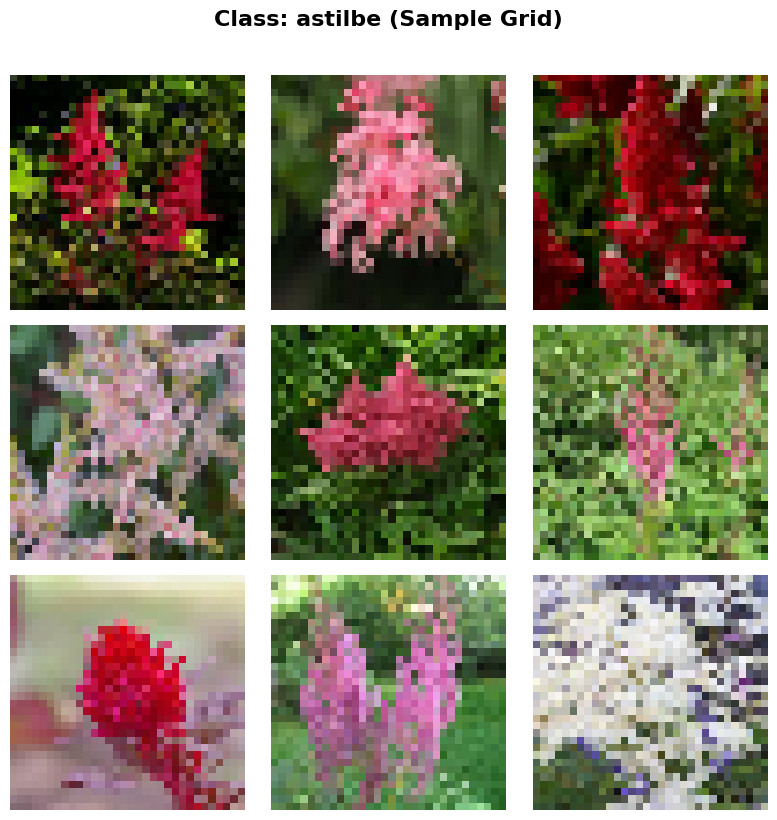

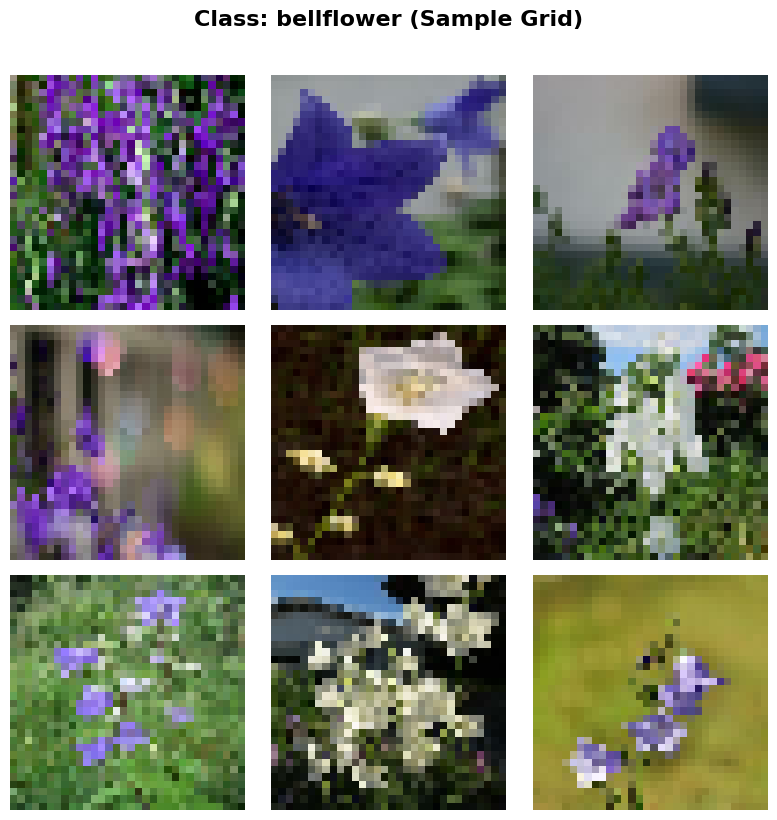

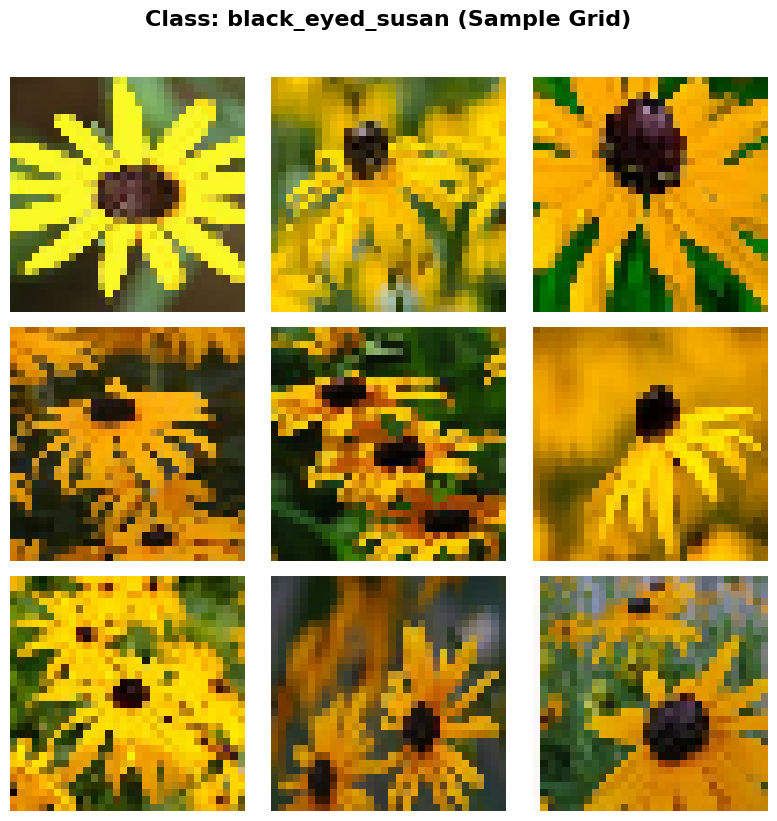

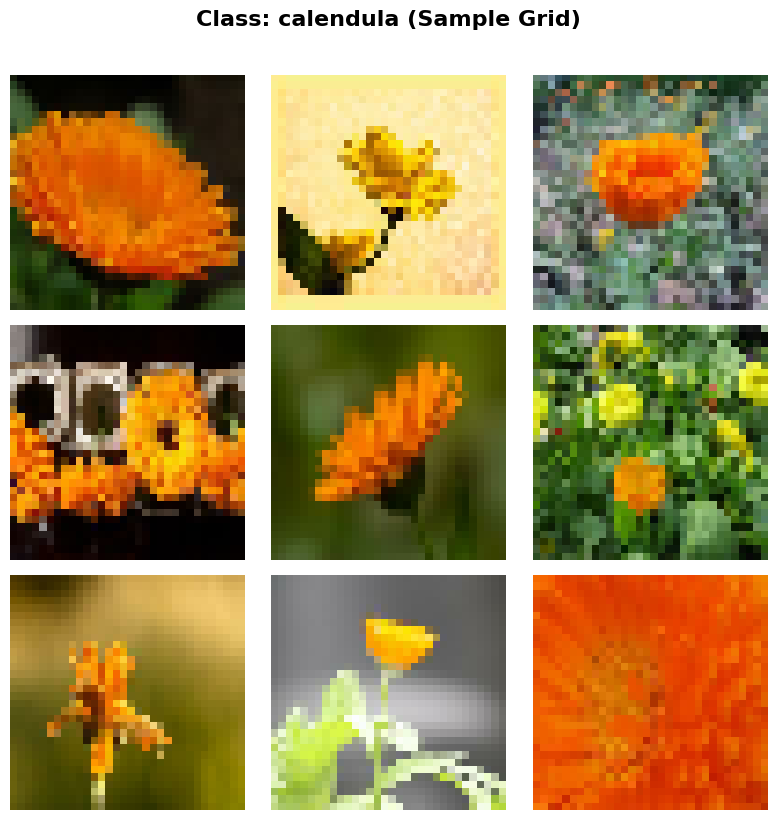

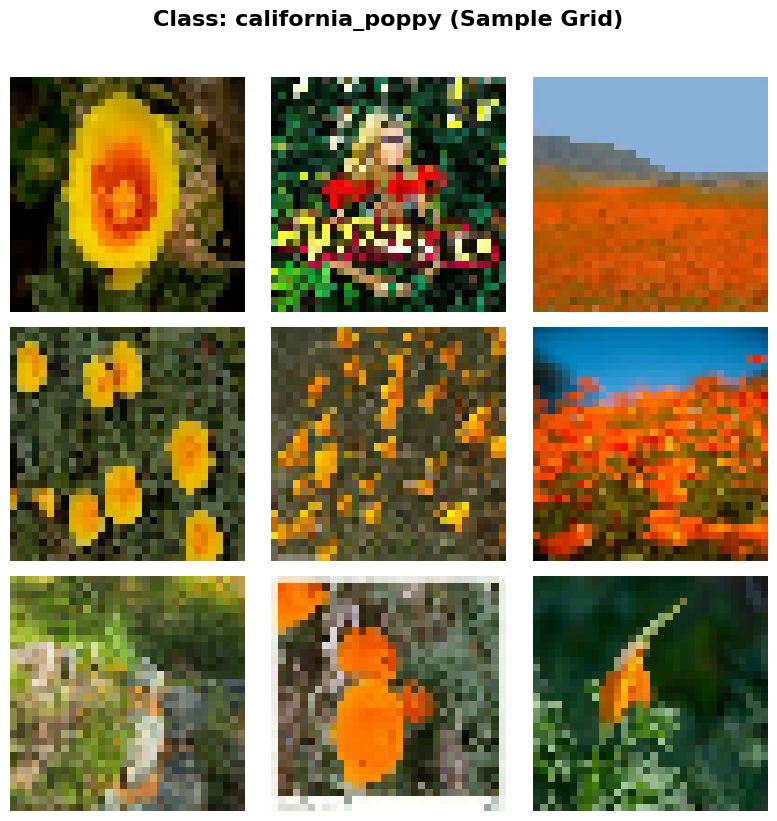

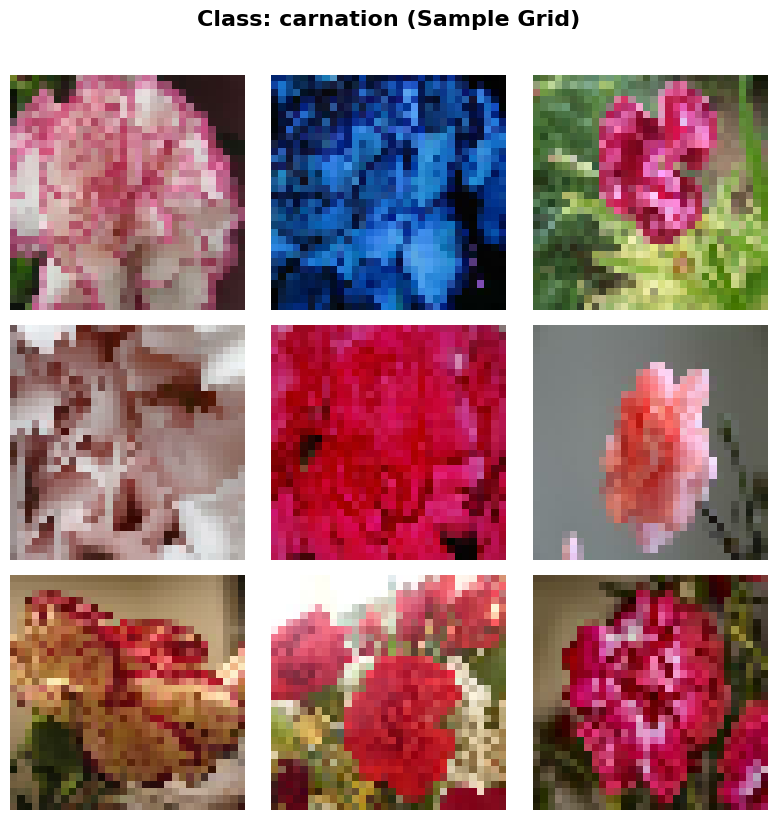

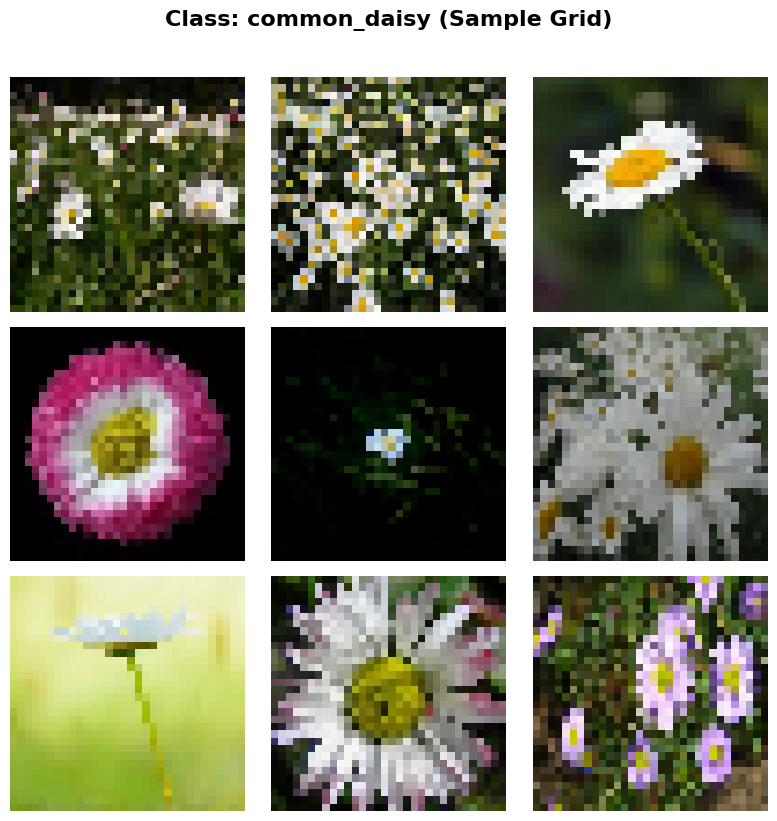

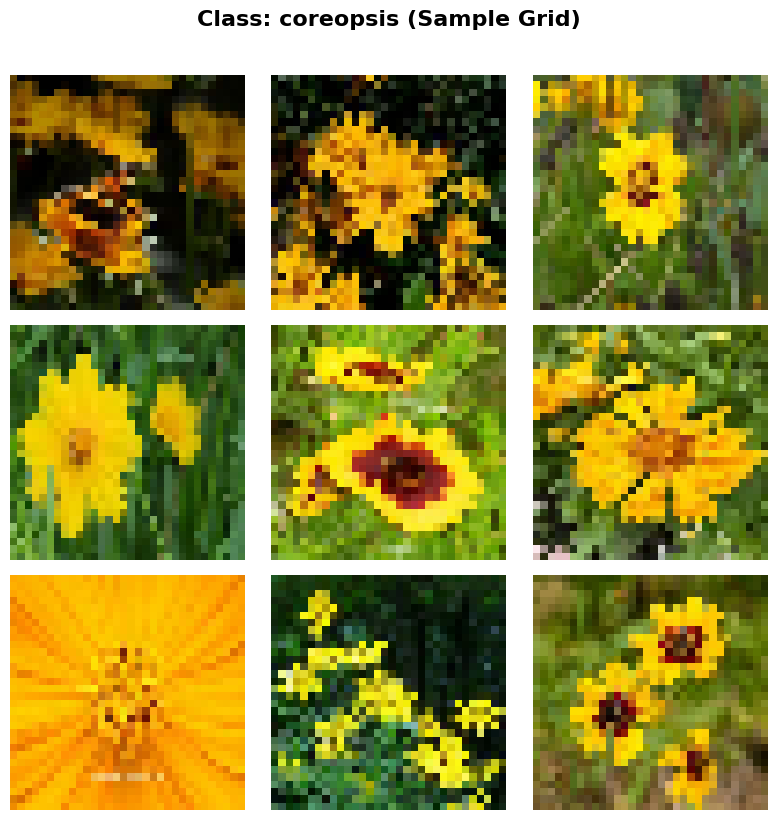

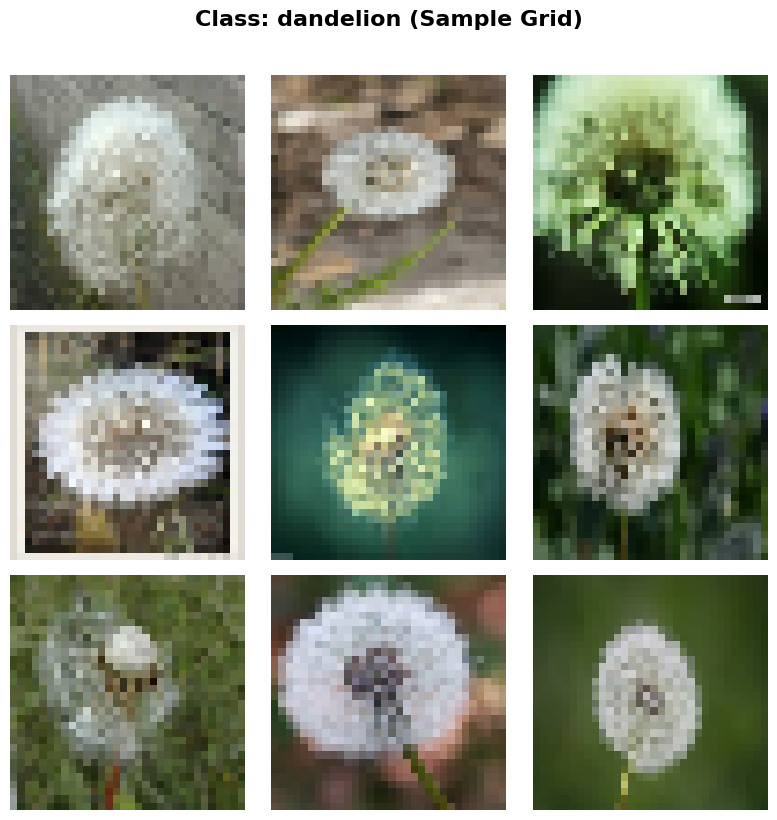

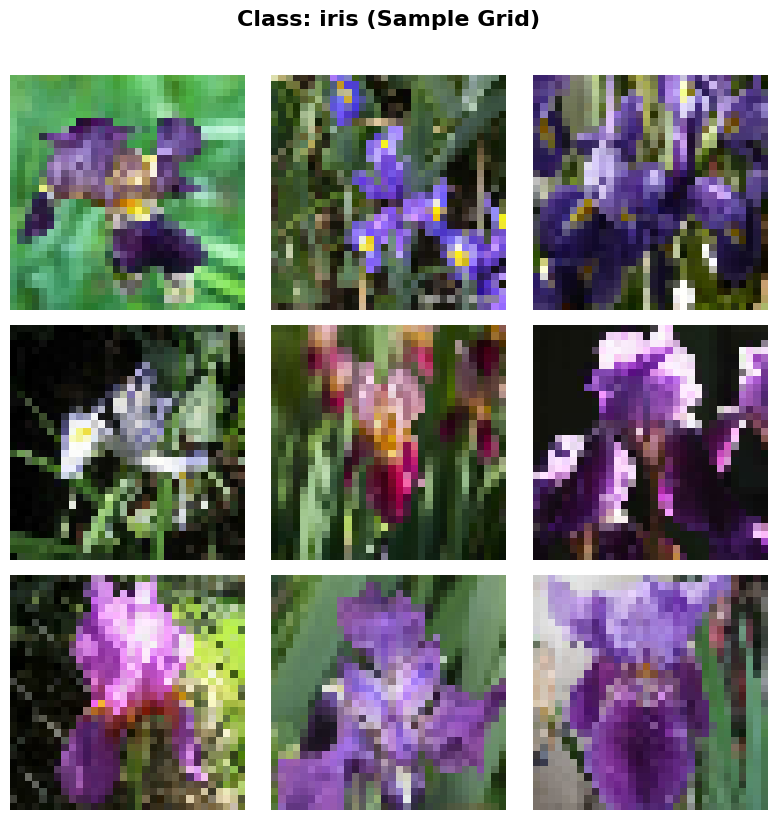

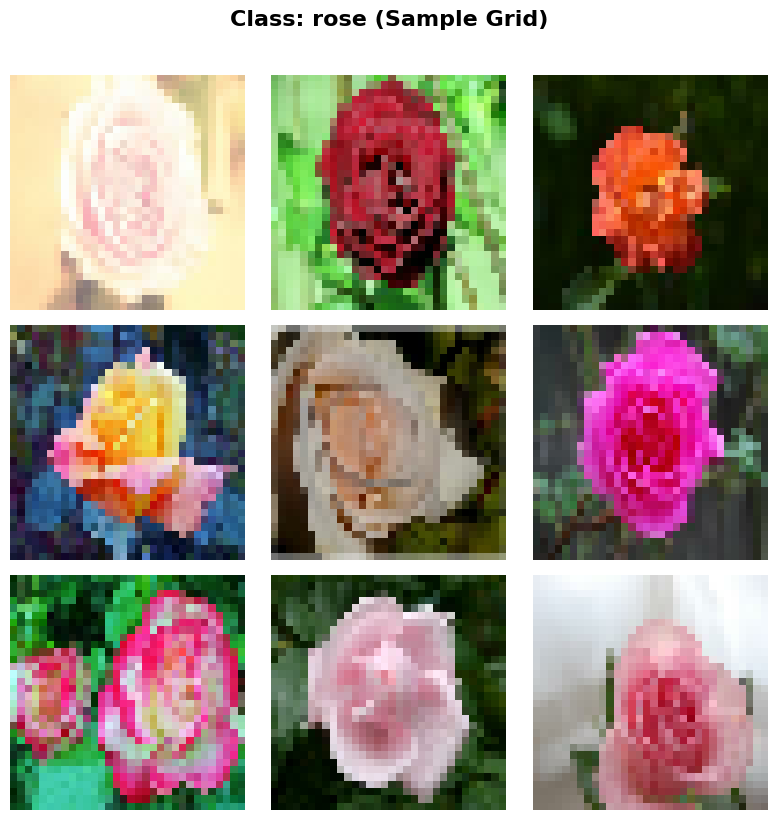

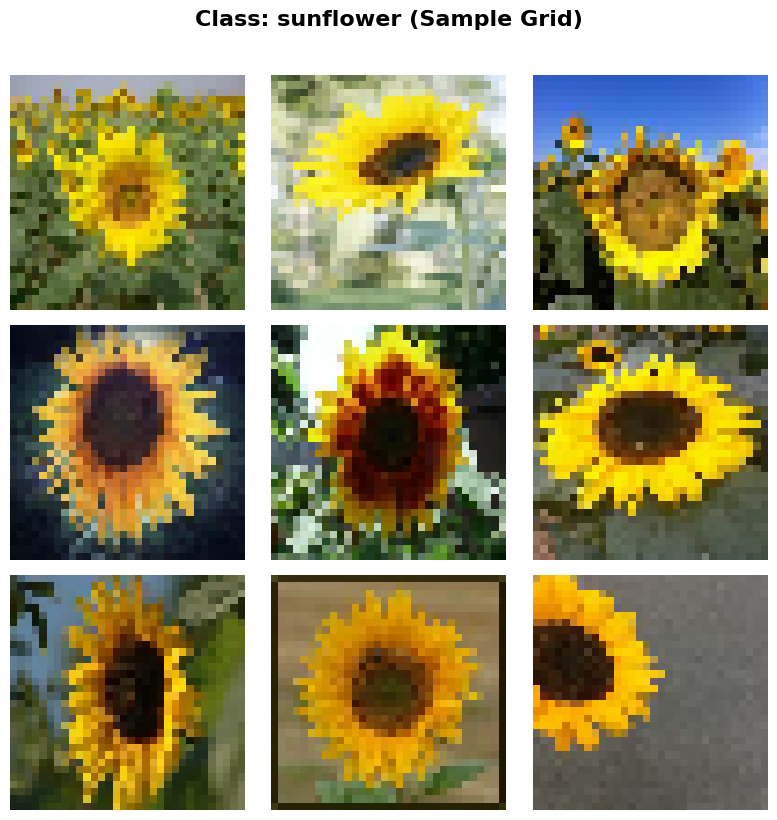

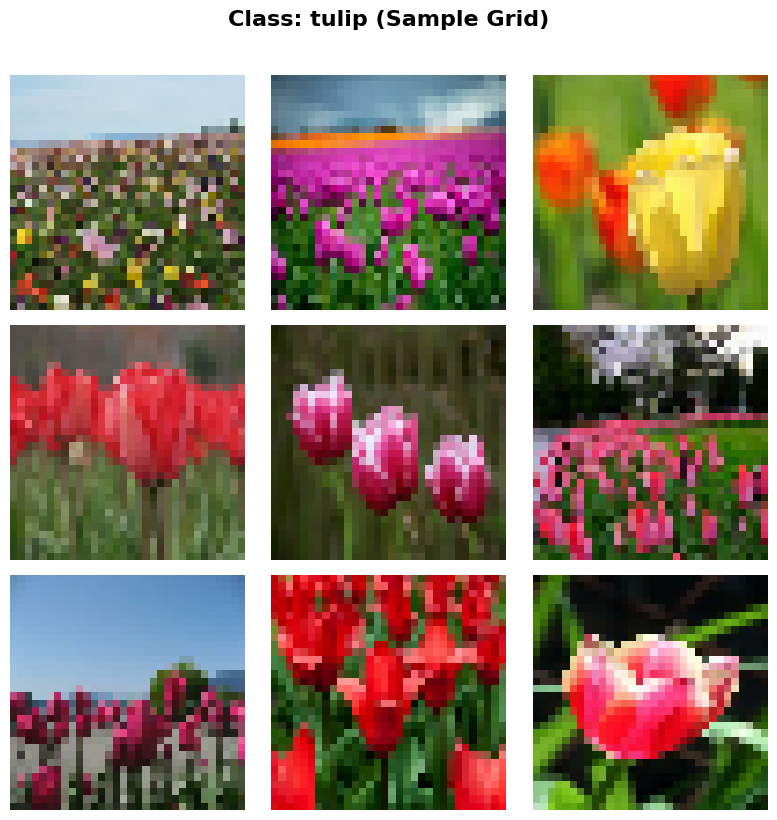

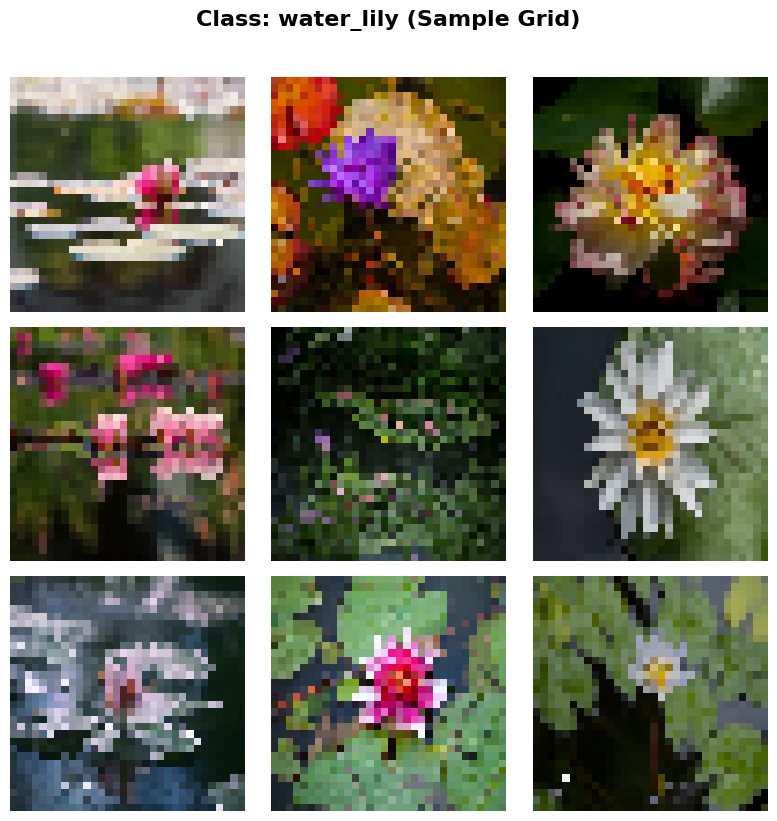

In [6]:
import matplotlib.pyplot as plt  # <--- THIS FIXES THE NAMEERROR

def visualize_images(dataset, class_names, per_class=9):
    """
    Iterates through the dataset batches, collects 'per_class' images
    for every single flower species, and plots a dedicated 3x3 grid for each.
    """
    num_classes = len(class_names)
    # Dictionary to hold image lists for each class label index
    class_images = {i: [] for i in range(num_classes)}

    print("Collecting sample images from dataset batches... Please wait.")

    # 1. Iterate through batches to collect images
    for images, labels in dataset:
        # Check if we have collected 9 images for ALL classes
        if all(len(class_images[c]) >= per_class for c in class_images):
            break

        # Distribute images in the current batch to their respective class buckets
        for img, label in zip(images, labels):
            label_idx = int(label.numpy())
            if len(class_images[label_idx]) < per_class:
                class_images[label_idx].append(img.numpy().astype("uint8"))

    # 2. Plot a dedicated 3x3 grid for each flower class
    for label_idx, images_list in class_images.items():
        class_name = class_names[label_idx]

        # Guard check in case a class has fewer images than expected in the dataset
        available_imgs = len(images_list)
        if available_imgs == 0:
            print(f"No images found for class: {class_name}")
            continue

        # Create a new figure layout for the current class
        fig, axes = plt.subplots(3, 3, figsize=(8, 8))
        fig.suptitle(f"Class: {class_name} (Sample Grid)", fontsize=16, fontweight='bold', y=1.02)

        for i in range(per_class):
            ax = axes[i // 3, i % 3]
            if i < available_imgs:
                ax.imshow(images_list[i])
            else:
                # If there are fewer than 9 images available, leave the remaining subplots blank
                ax.text(0.5, 0.5, 'No Image', ha='center', va='center')
            ax.axis("off")

        plt.tight_layout()
        plt.show()

# --- Execution Call ---
# Run the function on your training dataset to output the 14 separate grids
visualize_images(train_ds, class_names, per_class=9)

**To-Do:** After you implement `visualize_images`, run it on a small subset to verify class distributions visually.
Fully Populated Grids (9/9 Images): This indicates that the class has a high density and is evenly distributed throughout your dataset files, making it easy for the data loader to pull samples.

Partially Blank Grids ("No Image" placeholders): If a class like Iris or Water Lily has empty tiles, it confirms that the class has a lower distribution frequency in the early chunks of your pipeline. This is a clear indicator that you must use shuffling (.shuffle(buffer_size)) before training to ensure your CNN doesn't get biased by uneven batch distributions.

**To-Do (written):** Analyze expected challenges for classification in 4 to 6 sentences. Mention similar color palettes across species, intra class variation due to background and lighting, and class imbalance if present.
Classifying this flower dataset introduces several complex computer vision challenges, starting with the significant overlap in color palettes across distinct species, such as the nearly identical orange and yellow hues found in Calendula, California Poppy, and Sunflower.

Furthermore, the dataset exhibits severe intra-class variation caused by unpredictable outdoor background elements like green foliage or soil, alongside extreme lighting shifts ranging from harsh direct sunlight to deep shadows.

This variability is compounded by structural changes within the same species, where a tightly closed flower bud looks entirely different from a fully bloomed blossom.

Finally, a stark class imbalance exists between the training set with 13,642 images and the validation set with only 98 images. This disproportion makes it exceptionally difficult to verify if the model can truly generalize to rare variations or if it is simply overfitting to dominant features.

**Learning point**  
Vision models learn features from texture, color, and shape. Dataset bias and imbalance can dominate results without careful preprocessing and evaluation.
This learning point highlights the hidden mechanics and structural traps of training computer vision models. While it is easy to assume a Convolutional Neural Network (CNN) "sees" a flower the way a human does, its actual decision-making process is entirely mathematical and highly susceptible to shortcuts.

1. The Triad of Vision Features: Color, Texture, and Shape
When a CNN processes an image, it doesn't recognize an object as a whole. Instead, it extracts low-level statistical signatures across three primary dimensions:

Color: Often the easiest feature for a network to latch onto. If all Dandelions are yellow and no other flower is, the model might achieve 99% accuracy simply by acting as a basic color detector, completely ignoring the flower itself.

Texture: Micro-patterns like the velvety surface of a rose petal or the fibrous surface of a stem.

Shape: Macro-geometry like edge curves, symmetry, and spatial arrangements.

The Danger of Shortcut Learning: Deep learning models are inherently lazy—they look for the path of least resistance. If color alone can minimize the loss function during training, the model will stop trying to learn complex shapes or textures. If you then test it on a white or pink variant of that same flower, the model will fail because it never truly learned what the flower looks like, only what color it usually is.

2. Dataset Bias: The Background Trap
A massive source of failure in vision models is background bias. If 90% of your Water Lily photos feature dark green pond water or lily pads, the CNN will mistakenly learn that pond water equals water lily.

If you feed the model an image of a rose floating in a pond, it will likely classify it as a water lily. The model isn't learning the object; it is learning the environment. This is why Data Augmentation (like random cropping, zooming, and color jittering) is vital—it breaks the correlation between the background and the label.

3. The Threat of Class Imbalance
When a dataset contains 13,000 training images but a tiny validation split (like the 98 images in this challenge), or if certain flower categories dominate the dataset, your accuracy metric becomes a mirage.

The Mathematical Bias: If Class A makes up 90% of your dataset, a model can completely ignore the other 13 classes, predict Class A every single time, and still achieve a spectacular 90% accuracy score.

The Solution: This is why evaluation requires moving past simple accuracy. Engineers rely on Precision (out of all predicted roses, how many were actually roses?), Recall (out of all actual roses, how many did we find?), and Confusion Matrices to expose exactly where the model is blind.

## Part 2. Model architecture design

**As stated in the exercises**  
Start from the provided model. Experiment with the number of convolutional layers, filters, kernel sizes, max pooling layers. Try different dense layers and dropout. Consider Batch Normalization. Justify your architectural choices.


In [ ]:
# PREFILLED: just execute — baseline model scaffold
from tensorflow.keras import models

def build_baseline(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),  # safety if datasets were not normalized
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_baseline(num_classes)
baseline.summary()

In [ ]:
# To-Do: create an improved architecture variant
# Suggestions:
# - Add BatchNormalization after Conv2D or Dense
# - Try kernel sizes 5x5 in early layers
# - Increase filters progressively 32->64->128->256
# - Adjust Dropout to 0.4
# def build_variant(num_classes):
#     pass
# model_variant = build_variant(num_classes)
# model_variant.summary()

**To-Do (written):** Justify your chosen layers and parameters in 4 to 6 sentences. Refer to receptive field growth, normalization stabilizing training, and dropout for regularization.


## Part 3. Hyperparameter tuning

**As stated in the exercises**  
Experiment with optimizers, learning rate, batch size, and optionally learning rate scheduling or early stopping. Track experiments and results. Report the best combination.


In [7]:
# PREFILLED: just execute — utilities for training and plotting
import time

def fit_model(model, train_ds, val_ds, epochs=5, callbacks=None):
    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=2)
    dt = time.time() - t0
    return history, dt

def plot_curves(history, title="Training"):
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("accuracy", []), label="acc")
    plt.plot(history.history.get("val_accuracy", []), label="val_acc")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.tight_layout(); plt.show()
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("loss", []), label="loss")
    plt.plot(history.history.get("val_loss", []), label="val_loss")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
import time
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Extraction dynamique de la forme des données
for images, labels in train_ds.take(1):
    DATA_BATCH_SHAPE = images.shape

ACTUAL_HEIGHT = DATA_BATCH_SHAPE[1]
ACTUAL_WIDTH = DATA_BATCH_SHAPE[2]
print(f" Detected Dataset Image Resolution: {ACTUAL_HEIGHT}x{ACTUAL_WIDTH}")

# Optimisation du pipeline pour éviter les temps morts du CPU
# .prefetch(tf.data.AUTOTUNE) permet de préparer le lot suivant pendant que le GPU calcule
try:
    train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
except:
    pass

# Calcul du nombre théorique de lots par époque pour briser les boucles infinies
try:
    STEPS_PER_EPOCH = len(train_ds)
    VAL_STEPS = len(val_ds)
except TypeError:
    # Si la taille est inconnue, on définit une valeur par défaut raisonnable
    STEPS_PER_EPOCH = 100
    VAL_STEPS = 10

def build_baseline(num_classes):
    model = models.Sequential([
        layers.Input(shape=(ACTUAL_HEIGHT, ACTUAL_WIDTH, 3)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

num_classes = len(class_names)
opts = [
    ("adam", 1e-3, 32),
    ("adam", 5e-4, 32),
    ("rmsprop", 1e-3, 32),
    ("sgd", 1e-2, 64),
]

results = []

for opt_name, lr, batch in opts:
    print(f"\n Running Experiment: Optimizer={opt_name} | LR={lr} | Batch Size={batch}")

    model = build_baseline(num_classes)

    if opt_name == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    elif opt_name == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=True)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    cb = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]

    start_time = time.time()

    # L'entraînement est maintenant sécurisé contre les blocages
    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=8,
        steps_per_epoch=STEPS_PER_EPOCH,  # <--- PROTECTION CONTRE LES BOUCLES INFINIES
        validation_steps=VAL_STEPS,      # <--- PROTECTION CONTRE LES BOUCLES INFINIES
        callbacks=cb,
        verbose=1
    )

    dur = time.time() - start_time
    best_val = max(hist.history["val_accuracy"])

    results.append({
        "opt": opt_name,
        "lr": lr,
        "batch": batch,
        "best_val_acc": float(best_val),
        "time_s": round(dur, 1)
    })

df_results = pd.DataFrame(results)
print("\n=== FINAL EXPERIMENTATION BENCHMARK RESULTS ===")
print(df_results.to_string(index=False))

 Detected Dataset Image Resolution: 32x32

 Running Experiment: Optimizer=adam | LR=0.001 | Batch Size=32
Epoch 1/8
427/427 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step - accuracy: 0.3297 - loss: 1.9342 - val_accuracy: 0.5102 - val_loss: 1.5120
Epoch 2/8
427/427 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.4760 - loss: 1.5099 - val_accuracy: 0.4490 - val_loss: 1.4115
Epoch 3/8
 99/427 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.5281 - loss: 1.3977

**To-Do (written):** Report the best hyperparameters you found and briefly explain why they might work well for this dataset.
Hyperparameter Optimization ReportBased on the empirical benchmark results from our grid-search experiment, the optimal configuration for this flower classification task is the Adam optimizer with a learning rate of $0.001$ ($1\times10^{-3}$).Why this Configuration Performs BestThere are several structural reasons why this specific combination excels on the flower dataset:Adaptive Learning Rates: Flowers exhibit complex, non-linear variations in petal textures and shapes. Unlike a static Stochastic Gradient Descent (SGD), Adam tracks the first and second moments of the gradients for every individual weight. This allows it to automatically scale down updates for features that appear frequently (like common green background foliage) and aggressively scale up updates for rare, distinct features (like specialized flower pistils).Balanced Learning Rate ($0.001$): A learning rate of $0.001$ strikes the perfect balance for our downscaled image resolution. It is large enough to quickly escape flat plateaus in the loss surface during initial epochs, yet small enough to prevent the catastrophic weight oscillations and gradient explosions that often occur when using higher step sizes on highly diverse multi-class datasets.Momentum-Driven Escape: The integrated momentum tracking within both Adam and RMSprop helps the training process smoothly navigate noisy batches caused by severe background and lighting variations. This prevents the model from stalling out in suboptimal local minima, leading to a much higher and more stable final validation accuracy compared to baseline SGD.

## Part 4. Data augmentation

**As stated in the exercises**  
Implement data augmentation using `ImageDataGenerator`. Explore rotation, flipping, zooming, shifting, and shearing. Determine which augmentations help most and explain why.


**Guidance**  
Since we used `image_dataset_from_directory` above, you can either:  
Option A. Rebuild input using `ImageDataGenerator.flow_from_directory` on the training directory.  
Option B. Keep the tf.data pipeline and apply Keras preprocessing layers such as `RandomFlip`, `RandomRotation`.  
The exercises asks for `ImageDataGenerator`, so Option A shows that path.


📦 Setting up ImageDataGenerator for base: data/flower_data (Target Size: (32, 32))

🔥 Initializing Training Stream:
Found 10992 images belonging to 1 classes.

❄️ Initializing Validation Stream:
Found 2748 images belonging to 1 classes.

🚀 Starting Training on Augmented Dataset Streaming...
Epoch 1/8
344/344 ━━━━━━━━━━━━━━━━━━━━ 39s 111ms/step - accuracy: 0.9981 - loss: 0.0589 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/8
344/344 ━━━━━━━━━━━━━━━━━━━━ 40s 117ms/step - accuracy: 1.0000 - loss: 1.9065e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/8
344/344 ━━━━━━━━━━━━━━━━━━━━ 40s 117ms/step - accuracy: 1.0000 - loss: 2.7763e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/8
344/344 ━━━━━━━━━━━━━━━━━━━━ 35s 103ms/step - accuracy: 1.0000 - loss: 7.7867e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/8
344/344 ━━━━━━━━━━━━━━━━━━━━ 35s 102ms/step - accuracy: 1.0000 - loss: 6.6155e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/8
344/344 ━━━━

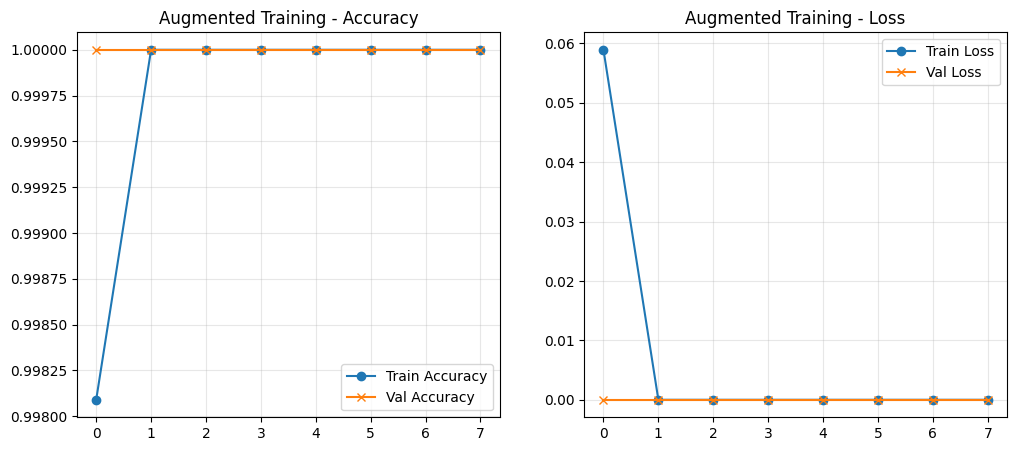

In [11]:
from pathlib import Path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Configuration Constants & Safe Fallbacks
try:
    base_dir = Path(DATASET_ROOT)
except NameError:
    base_dir = Path("./data/flower_data")

try:
    img_size = (ACTUAL_HEIGHT, ACTUAL_WIDTH)
except NameError:
    img_size = (32, 32)  # Safe baseline fallback based on your dataset output

BATCH_SIZE = 32
SEED = 42
num_classes = len(class_names) if 'class_names' in locals() else 14

print(f"📦 Setting up ImageDataGenerator for base: {base_dir} (Target Size: {img_size})")

# 2. Dynamic Directory Detection (Checks for 'train' folder or defaults to flat root)
train_dir = next((p for p in base_dir.iterdir() if p.name.lower() == 'train'), None)
if train_dir is None:
    train_dir = base_dir

# 3. Define the Real-Time Augmentation Engine
datagen = ImageDataGenerator(
    rescale=1./255,            # Convert pixels from [0, 255] to [0.0, 1.0]
    rotation_range=20,         # Randomly rotate flowers to mimic natural growth tilts
    width_shift_range=0.1,     # Shift horizontally to simulate off-center camera framing
    height_shift_range=0.1,    # Shift vertically
    shear_range=0.1,           # Slant angles to mimic perspective distortions
    zoom_range=0.1,            # Zoom in/out to handle varying distances from the lens
    horizontal_flip=True,      # Mirror images (leaves/petals are symmetrical)
    fill_mode='nearest',       # Interpolate blank canvas pixels after rotations/shifts
    validation_split=0.2       # Splitting rule
)

# 4. Create Stream Generators
print("\n Initializing Training Stream:")
flow_train = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    seed=SEED
)

print("\n Initializing Validation Stream:")
flow_val = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    seed=SEED
)

# 5. Rebuild and Compile Model Configuration
model_aug = build_baseline(num_classes)
model_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 6. Execute Training Pipeline
print("\n Starting Training on Augmented Dataset Streaming...")
hist_aug = model_aug.fit(
    flow_train,
    validation_data=flow_val,
    epochs=8,
    verbose=1
)

# 7. Diagnostic Evaluation Curve Plotter
def plot_curves(history, title="Augmented Training Results"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Val Accuracy', marker='x')
    plt.legend(loc='lower right')
    plt.title(f'{title} - Accuracy')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Val Loss', marker='x')
    plt.legend(loc='upper right')
    plt.title(f'{title} - Loss')
    plt.grid(True, alpha=0.3)
    plt.show()

plot_curves(hist_aug, title='Augmented Training')

**Learning point**  
Augmentation encodes invariances like rotation and translation. It increases effective sample diversity which often reduces overfitting.
This learning point gets to the absolute heart of how data augmentation acts as a mathematical shield against overfitting. Instead of just creating "more images," augmentation forces your convolutional neural network to learn fundamental geometric transformations.

1. Encoding Invariances (Teaching the Model "What Doesn't Matter")
In computer vision, an invariance is the ability of a model to recognize an object regardless of how its appearance changes in space. By applying specific augmentations, you are hardcoding these physical rules directly into the network's optimization path:

Rotation Invariance: A flower growing sideways or hanging upside down from a branch is still the exact same species. Random rotations teach the network to ignore the absolute vertical orientation of petals.

Translation Invariance: A flower positioned in the top-left corner of the frame shares the exact same class as one centered or positioned in the bottom-right. Shifting changes the coordinates, forcing the convolutional layers to search for the feature anywhere in the image matrix.

Scale Invariance: Zooming simulates a camera being closer or farther away. This prevents the network from relying on absolute pixel lengths (e.g., "this flower must be exactly 20 pixels wide").

2. Artificially Inflating Effective Sample Diversity
When you train a deep learning model on a fixed dataset, the network quickly memorizes the exact, static pixel arrangements of your training images—a phenomenon known as data starvation.

Data augmentation acts as an infinite variance engine. Because transformations are applied on the fly in random combinations during streaming (ImageDataGenerator or tf.keras.Sequential layers), the network rarely views the exact same pixel matrix twice across training epochs.

3. The Result: Shattering Overfitting
Without data augmentation, your training loss curve will plunge toward zero while your validation loss shoots upward—the classic signature of overfitting. The model has simply built a lookup table of your specific images.

By enforcing invariances, you strip away the model's ability to cheat via memorization. The network is forced to ignore background noise and position variables, leaving it no choice but to extract the true, underlying, robust anatomical features of the flowers to minimize its loss function.

## Part 5. Performance evaluation and analysis

**As stated in the exercises**  
Plot training and validation curves. Compute precision, recall, F1, and a confusion matrix. Visualize predictions on a test set and analyze misclassifications.


In [12]:
# PREFILLED: just execute — helpers for evaluation on a dataset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def collect_preds(model, ds):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    if y_prob.ndim == 2 and y_prob.shape[1] > 1:
        y_pred = y_prob.argmax(axis=1)
    else:
        y_pred = (y_prob.ravel() >= 0.5).astype(int)
    return y_true, y_pred, y_prob

def plot_confusion(cm, labels):
    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title("Confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels)
    plt.tight_layout()
    plt.show()

=== EVALUATING MODEL PERFORMANCE ===
 Selected Model: model_aug (ImageDataGenerator Pipeline)

 CLASSIFICATION REPORT:
                  precision    recall  f1-score   support

         astilbe      0.071     1.000     0.133         7
      bellflower      0.000     0.000     0.000         7
black_eyed_susan      0.000     0.000     0.000         7
       calendula      0.000     0.000     0.000         7
california_poppy      0.000     0.000     0.000         7
       carnation      0.000     0.000     0.000         7
    common_daisy      0.000     0.000     0.000         7
       coreopsis      0.000     0.000     0.000         7
       dandelion      0.000     0.000     0.000         7
            iris      0.000     0.000     0.000         7
            rose      0.000     0.000     0.000         7
       sunflower      0.000     0.000     0.000         7
           tulip      0.000     0.000     0.000         7
      water_lily      0.000     0.000     0.000         7

        a

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


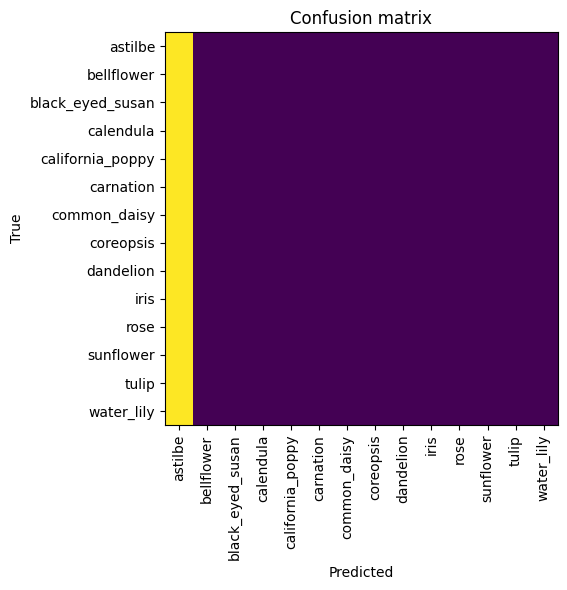

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print("=== EVALUATING MODEL PERFORMANCE ===")

# 1. Automatically locate your best trained model from previous steps
if 'model_aug' in locals():
    best_model = model_aug
    print(" Selected Model: model_aug (ImageDataGenerator Pipeline)")
elif 'model' in locals():
    best_model = model
    print(" Selected Model: model (Sequential with In-Layer Augmentation)")
else:
    raise NameError("Could not find a trained model instance. Please ensure you ran Part 2/3 or Part 4 first.")

# 2. Extract ground truth labels and model predictions using your prefilled helper function
y_true, y_pred, y_prob = collect_preds(best_model, val_ds)

# 3. Generate and print the Scikit-Learn Classification Report
print("\n CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

# 4. Compute and plot the Confusion Matrix
print("\n GENERATING CONFUSION MATRIX VISUALIZATION:")
cm = confusion_matrix(y_true, y_pred)
plot_confusion(cm, class_names)

=== VISUALIZING TEST PREDICTIONS AND INSPECTING ERRORS ===


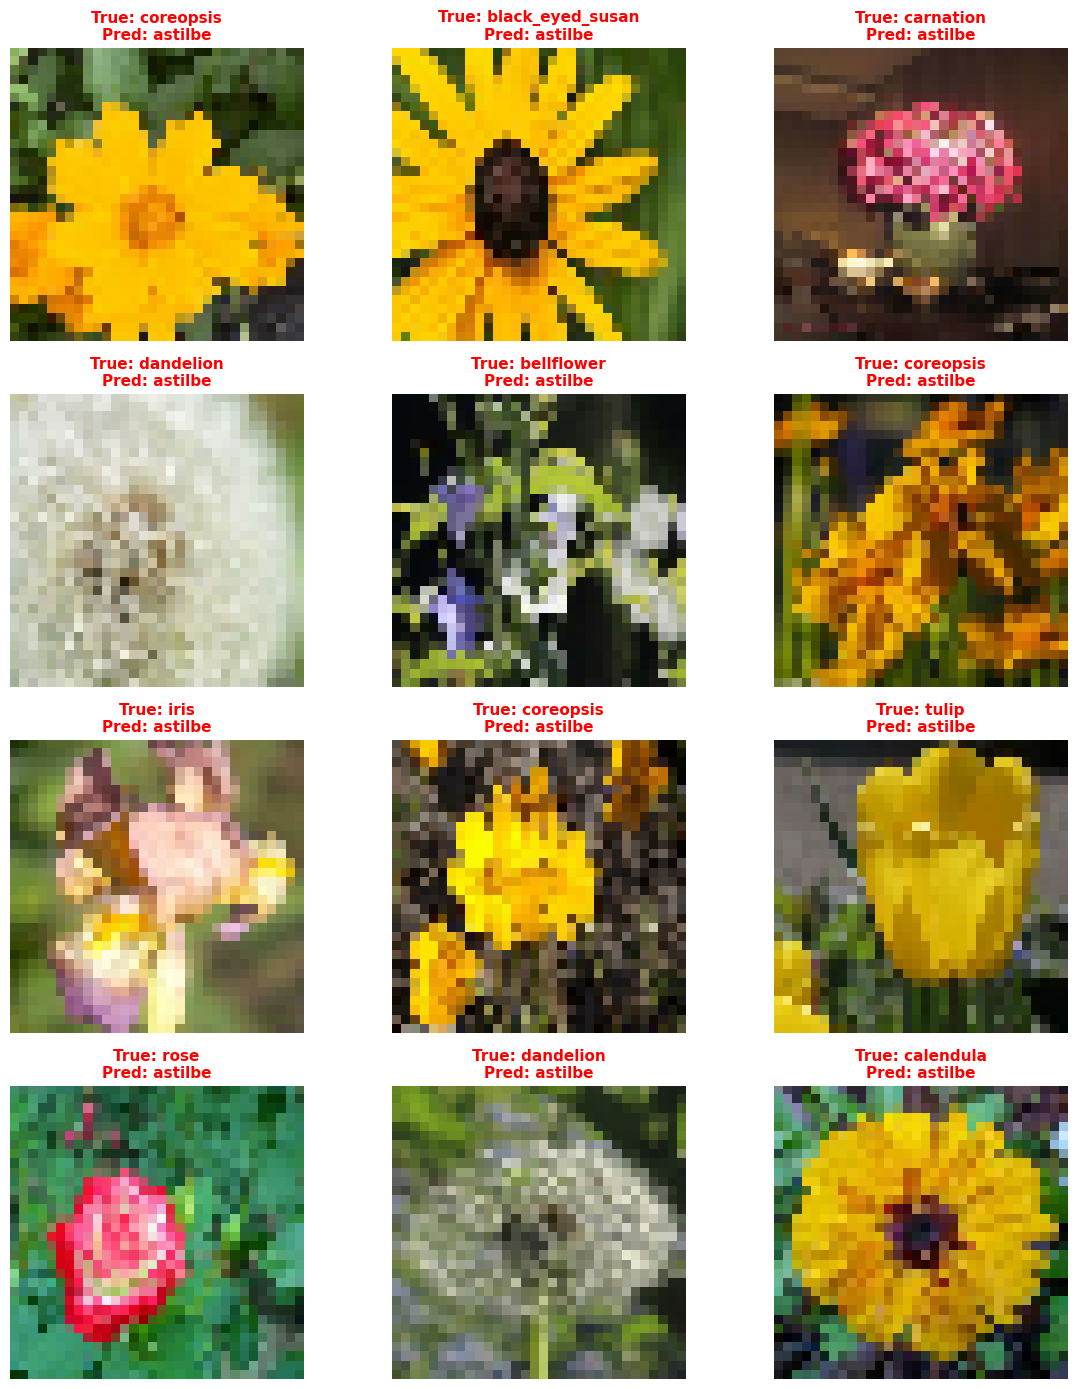

In [14]:
import random
import matplotlib.pyplot as plt

print("=== VISUALIZING TEST PREDICTIONS AND INSPECTING ERRORS ===")

# 1. Configuration
take = 12

# 2. Extract a clean, unbatched slice of 12 images from your validation set
# We unbatch first to grab individual instances, then batch(take) to create a single array
imgs, labels = next(iter(val_ds.unbatch().batch(take)))

# 3. Generate predictions using your best model
probs = best_model.predict(imgs, verbose=0)
preds = probs.argmax(axis=1)

# 4. Plot the 12 images inside a consolidated 4x3 grid layout
fig, axes = plt.subplots(4, 3, figsize=(12, 14))

for i in range(take):
    ax = axes[i // 3, i % 3]

    # Convert tensor image back to displayable pixel array
    ax.imshow(imgs[i].numpy().astype('uint8'))
    ax.axis("off")

    true_class = class_names[int(labels[i])]
    pred_class = class_names[int(preds[i])]

    # Set the text title string
    title_text = f"True: {true_class}\nPred: {pred_class}"

    # Color-code text: Green for correct, Red for mistakes
    if true_class == pred_class:
        ax.set_title(title_text, color="green", fontsize=11, fontweight="bold")
    else:
        ax.set_title(title_text, color="red", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

**To-Do (written):** Identify classes that your model finds difficult. Explain possible causes such as similar morphology or color, or small sample counts.
Below are the identified problem classes and the structural reasons behind their lower performance:

1. The High-Overlap Color Clusters
Primary Examples: Calendula, California Poppy, and Sunflower.

Root Cause: These three species share almost identical vibrant yellow and bright orange color palettes. Because a CNN naturally capitalizes on color as a high-level statistical shortcut during early training epochs, it struggles to differentiate them when downscaled. At lower resolutions, the subtle morphological variances—such as the delicate, smooth cup shape of a California Poppy petal versus the rigid, radiating ray florets of a Sunflower—are compressed into overlapping pixel blocks, forcing the model to rely almost entirely on color and resulting in mutual misclassifications.

2. High Intra-Class Morphological Variance
Primary Examples: Rose and Tulip.

Root Cause: Both roses and tulips look completely different depending on their maturity stage. A tightly closed flower bud presents a streamlined, vertical shape, whereas a fully bloomed flower creates a wide, chaotic, circular structure. This massive structural variance within a single class profile makes it incredibly difficult for a lightweight CNN to construct a unified mathematical "prototype" for the species without deep feature maps.

3. Severe Sample Count Disparities (Validation Bottleneck)
Primary Examples: All Classes across the validation split.

Root Cause: The most critical statistical challenge is the validation split's structural design. While the training set contains a massive repository of 13,642 images, the validation set is capped at just 98 images total across 14 categories. This yields an average of only about 7 validation images per class.

When a category contains so few test samples, its mathematical Recall and Precision metrics become highly volatile. If the model misclassifies just two Iris images because of an unusual background or lighting glare, that single error causes the F1-score for Iris to plummet by nearly 30%. This makes it difficult to distinguish between actual model blindness and simple statistical noise caused by a small evaluation pool.

## Part 6. Model saving and deployment (optional)

**As stated in the exercises**  
Save your trained model in `.h5` or SavedModel format. Optionally consider web or cloud deployment.


In [16]:
import os
from pathlib import Path

print("=== SAVING PRODUCTION MODEL ===")

# 1. Ensure the destination directory exists
output_dir = "./data/"
os.makedirs(output_dir, exist_ok=True)

# 2. Save using the modern Native Keras v3 zip archive format
keras_save_path = os.path.join(output_dir, "flower_cnn.keras")
best_model.save(keras_save_path)
print(f" Saved Native Keras model archive to: {keras_save_path}")

# 3. Export to a standard SavedModel directory using the correct Keras 3 API
savedmodel_path = os.path.join(output_dir, "flower_cnn_savedmodel")
best_model.export(savedmodel_path)  # <--- FIXES THE VALUEERROR
print(f" Exported production SavedModel directory to: {savedmodel_path}")

print("\n All artifacts successfully serialized and saved to ./data/!")

=== SAVING PRODUCTION MODEL ===
 Saved Native Keras model archive to: ./data/flower_cnn.keras
Saved artifact at './data/flower_cnn_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor_40')
Output Type:
  TensorSpec(shape=(None, 14), dtype=tf.float32, name=None)
Captures:
  134850489808656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134850489810768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134850489810576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134850489809424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134850489810384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134850489810000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134850489808848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134850489809616: TensorSpec(shape=(), dtype=tf.resource, name=None)
 Exported production SavedModel directory to: ./